<a href="https://colab.research.google.com/github/EkaterinaLavlinskaya/simple_nn_binary_torch/blob/main/simple_nn_binary_torch3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Простая нейросеть для бинарной классификации в torch

In [ ]:
import torch
import torch.nn as nn
import numpy as np
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tqdm
from tqdm.auto import tqdm

In [ ]:
# Генерация данных
X, y = make_blobs(n_samples=1500, centers=[[-2,0.5],[3,-0.5]], cluster_std=1, random_state=50)

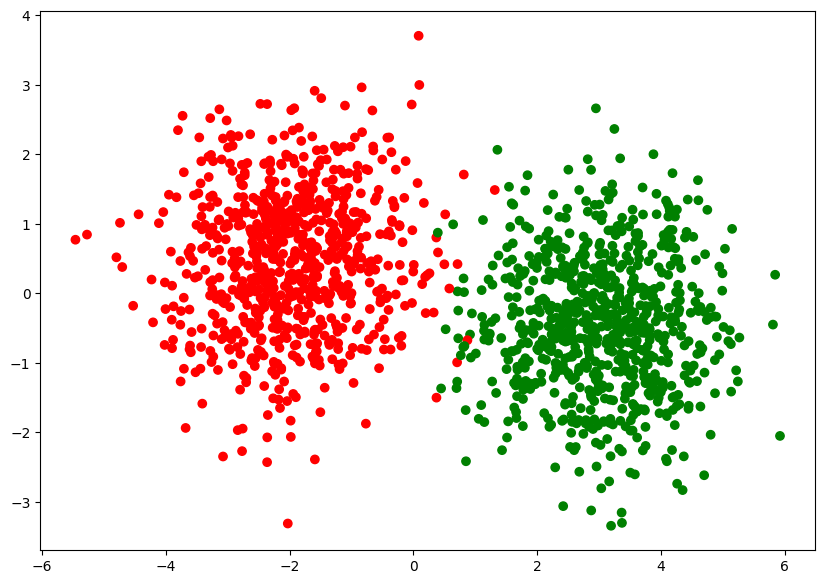

In [ ]:
# Визуализация данных
colors = ("red", "green")
colored_y = np.zeros(y.size, dtype=str)
for i, cl in enumerate([0,1]):
    colored_y[y.ravel() == cl] = str(colors[i])

plt.figure(figsize=(10,7))
plt.scatter(X[:, 0], X[:, 1], c=colored_y)
plt.show()


In [ ]:
# Разделение на train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=200, random_state=42)

In [ ]:
#  Нормализация данных
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# Преобразование в тензоры
X_train_tensor = torch.FloatTensor(X_train_scaled)
y_train_tensor = torch.FloatTensor(y_train).view(-1, 1)  # [1000] -> [1000, 1]
X_test_tensor = torch.FloatTensor(X_test_scaled)

In [ ]:
# 5. Определение модели
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        # Увеличим размер скрытого слоя для лучшего обучения
        self.fc1 = nn.Linear(2, 4)  # 2 входа -> 4 нейрона
        self.act1 = nn.ReLU()  # ReLU работает лучше для скрытых слоев

        self.fc2 = nn.Linear(4, 1)  # 4 входа -> 1 выход
        self.act2 = nn.Sigmoid()  # Sigmoid для бинарной классификации

    def forward(self, x):
        x = self.fc1(x)
        x = self.act1(x)
        x = self.fc2(x)
        x = self.act2(x)
        return x


In [ ]:
# Создание модели
model = Net()
print(model)

Net(
  (fc1): Linear(in_features=2, out_features=4, bias=True)
  (act1): ReLU()
  (fc2): Linear(in_features=4, out_features=1, bias=True)
  (act2): Sigmoid()
)


In [ ]:
# Функция обучения
def train(model, X, y, criterion, optimizer, num_epoch):
    model.train()
    losses = []

    for t in tqdm(range(num_epoch)):

        y_pred = model(X)

        # Вычисление loss
        loss = criterion(y_pred, y)
        losses.append(loss.item())

        # Обратный проход
        optimizer.zero_grad()  # Обнуляем градиенты ДО backward
        loss.backward()
        optimizer.step()  # Обновляем веса

        # Выводим прогресс каждые 30 эпох
        if t % 30 == 0:
          print(f"Эпоха {t}, Loss: {loss.item():.4f}")

    return model, losses


In [ ]:
# Компоненты обучения
criterion = nn.BCELoss()  # Для бинарной классификации
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)  # Adam работает лучше SGD

In [ ]:
# Обучение

model, losses = train(model, X_train_tensor, y_train_tensor, criterion, optimizer, 150)

  0%|          | 0/150 [00:00<?, ?it/s]

Эпоха 0, Loss: 0.8221
Эпоха 30, Loss: 0.5417
Эпоха 60, Loss: 0.3442
Эпоха 90, Loss: 0.2508
Эпоха 120, Loss: 0.1947


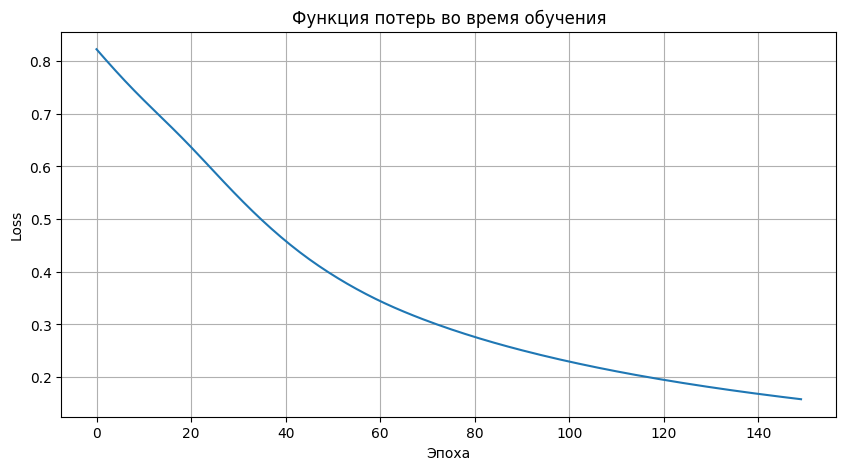

In [ ]:
# Визуализация процесса обучения
plt.figure(figsize=(10,5))
plt.plot(losses)
plt.title('Функция потерь во время обучения')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

In [ ]:
# Предсказание
model.eval()  # Переводим модель в режим оценки
with torch.no_grad():
    # Получаем вероятности
    probabilities = model(X_test_tensor)

    # Преобразуем в классы (0 или 1) с порогом 0.5
    predictions = (probabilities > 0.5).float()

    # Преобразуем в numpy для удобства
    predictions_np = predictions.numpy().flatten()
    probabilities_np = probabilities.numpy().flatten()

In [ ]:
#Сравниваем способы предсказаний
#Способ 1
with torch.no_grad():
    # Получаем предсказания модели (вероятности)
    nn_prediction_probs = model(X_test_tensor)

    # Преобразуем в список
    nn_prediction_list = nn_prediction_probs.tolist()

    # Применяем порог 0.5 для получения классов
    nn_prediction_classes = np.array([int(x[0] > 0.5) for x in nn_prediction_list])

# Способ 2
with torch.no_grad():
    probabilities = model(X_test_tensor)
    predictions = (probabilities > 0.5).float()

# Сравним результаты
print(f"Способ 1 (первые 5): {nn_prediction_classes[:5]}")
print(f"Способ 2 (первые 5): {predictions.numpy().flatten()[:5]}")


Способ 1 (первые 5): [0 0 1 0 0]
Способ 2 (первые 5): [0. 0. 1. 0. 0.]


In [ ]:
# Оценка качества
from sklearn.metrics import accuracy_score, classification_report

accuracy = accuracy_score(y_test, predictions_np)
print(accuracy)

1.0


In [ ]:
# Примеры предсказаний
print("\nПримеры предсказаний (первые 10):")
for i in range(min(10, len(X_test))):
    print(f"Вероятность: {probabilities_np[i]:.3f} -> Класс: {int(predictions_np[i])}, Истинный класс: {y_test[i]}")


Примеры предсказаний (первые 10):
Вероятность: 0.231 -> Класс: 0, Истинный класс: 0
Вероятность: 0.231 -> Класс: 0, Истинный класс: 0
Вероятность: 0.998 -> Класс: 1, Истинный класс: 1
Вероятность: 0.231 -> Класс: 0, Истинный класс: 0
Вероятность: 0.231 -> Класс: 0, Истинный класс: 0
Вероятность: 0.994 -> Класс: 1, Истинный класс: 1
Вероятность: 0.973 -> Класс: 1, Истинный класс: 1
Вероятность: 0.231 -> Класс: 0, Истинный класс: 0
Вероятность: 0.997 -> Класс: 1, Истинный класс: 1
Вероятность: 0.231 -> Класс: 0, Истинный класс: 0


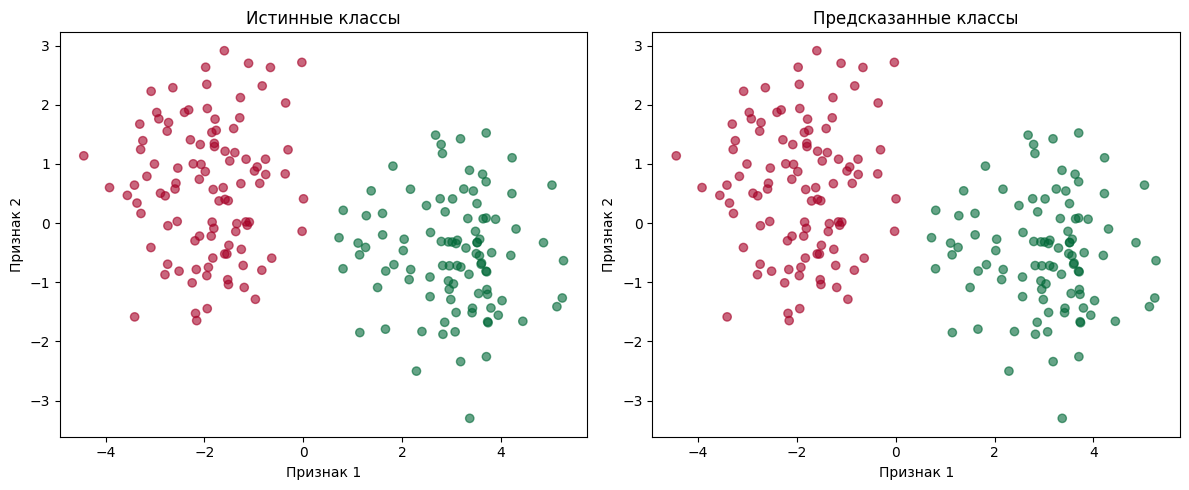

In [ ]:
# Визуализация результатов
plt.figure(figsize=(12,5))

# График 1: Исходные данные
plt.subplot(1,2,1)
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap='RdYlGn', alpha=0.6)
plt.title('Истинные классы')
plt.xlabel('Признак 1')
plt.ylabel('Признак 2')

# График 2: Предсказания
plt.subplot(1,2,2)
plt.scatter(X_test[:, 0], X_test[:, 1], c=predictions_np, cmap='RdYlGn', alpha=0.6)
plt.title('Предсказанные классы')
plt.xlabel('Признак 1')
plt.ylabel('Признак 2')

plt.tight_layout()
plt.show()

In [ ]:
import json
import glob
import os

# Находим любой .ipynb файл в текущей папке
notebook_files = glob.glob('/content/*.ipynb')

if not notebook_files:
    print("❌ Файл .ipynb не найден!")
    print("Сначала сохрани ноутбук: Файл → Сохранить")
else:
    # Берём первый найденный файл
    original_file = notebook_files[0]
    print(f"✅ Найден файл: {original_file}")

    # Читаем и удаляем widgets
    with open(original_file, 'r', encoding='utf-8') as f:
        nb = json.load(f)

    if 'widgets' in nb.get('metadata', {}):
        del nb['metadata']['widgets']
        print("✅ metadata.widgets удалён")
    else:
        print("ℹ️ metadata.widgets не найден")

    # Сохраняем исправленный файл
    fixed_file = '/content/notebook_fixed.ipynb'
    with open(fixed_file, 'w', encoding='utf-8') as f:
        json.dump(nb, f, indent=1, ensure_ascii=False)

    print(f"\n🎉 Готово! Скачай файл: {fixed_file}")
    print("📥 Нажми на три точки справа от файла → Скачать")

❌ Файл .ipynb не найден!
Сначала сохрани ноутбук: Файл → Сохранить
